In [2]:
import numpy as np
import pandas as pd

In [3]:
phy_marks = np.random.randint(0, 100, size=(10000,))
chem_marks = np.random.randint(0, 100, size=(10000,))
math_marks = np.random.randint(0, 100, size=(10000,))
com_marks = np.random.randint(0, 100, size=(10000,))

# compact each books
subjects = np.asarray([phy_marks, chem_marks, math_marks, com_marks], dtype=float)
m = subjects.shape[0] # total no. of features

# CALCULATES:
# average marks
avg_marks = np.mean(subjects, axis=0)

# total marks
total_marks = np.sum(subjects, axis=0)

# % percentage
percentages = total_marks / (100 * m) * 100
per = np.round(percentages, 2)

# final result
final_results = np.all(subjects >= 35, axis=0)
results = []
for res in final_results:
    if res:
        results.append('PASS')
    else:
        results.append("FAIL")

# Grades: [A+: 90+, A: 80+, B+: 70+, B: 60+, C+: 50+, C: 35+, D: Fail]
conditions = [
    percentages >= 90,
    percentages >= 80,
    percentages >= 70,
    percentages >= 60,
    percentages >= 50,
    percentages >= 35,
]

grades = ['A+', 'A', 'B+', 'B', 'C+', 'C']
final_grade = np.select(conditions, grades, default='NG')

df = pd.DataFrame({
    "Physics":phy_marks, 
    "Chemistry":chem_marks,
    "Math":math_marks,
    "Computer":com_marks,
    "Average Marks":avg_marks,
    "Total Marks": total_marks,
    "Percentages %":per,
    "Grades":final_grade,
    "Final Results":results
})  

# convert dataframe into csv file
df.to_csv('studentsMarks.csv', index=False)

# total pass and fail 
df['Final Results'].value_counts()

Final Results
FAIL    8180
PASS    1820
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x218c99c6850>,
 [Text(0.03007524650520666, 1.0995887774744024, ''),
  Text(-0.03007541253849245, -1.0995887729331542, '')],
 [Text(0.02378678587229981, 0.8696747603661183, '49.1%'),
  Text(-0.023786917189534938, -0.8696747567744036, '50.9%')])

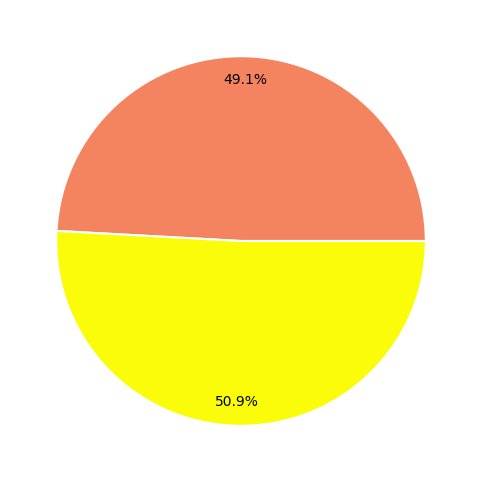

In [18]:
from matplotlib import pyplot as plt

std_df = pd.read_csv('studentsMarks.csv')
marks = std_df.iloc[:, :2]
cols = std_df.columns[:2]
COLORS = ["#F4845F", "#FAFC09"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.pie(
    std_df['Average Marks'][:2],
    autopct="%1.1f%%",
    colors=COLORS[: len(cols)],
    pctdistance=0.87,
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"}
    )
    
